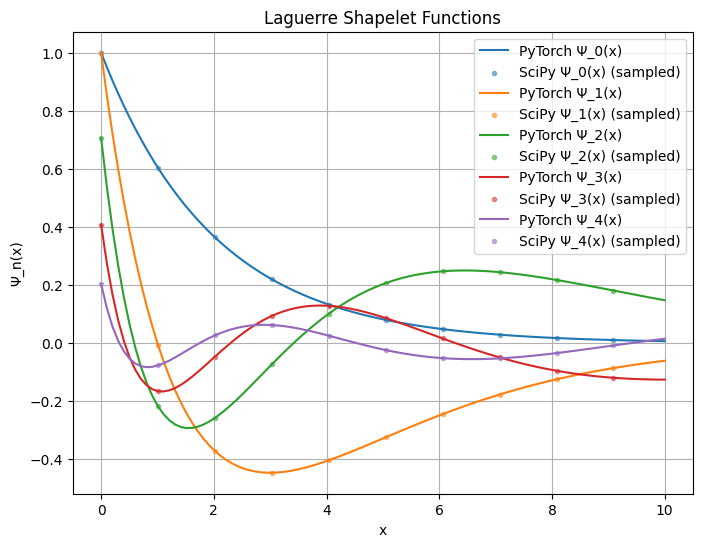

Input x: 2.0
Output y = Ψ_2(x): -0.26013004779815674
Gradient dy/dx: 0.13006502389907837
Gradient tracking works: True


In [1]:
import torch
import scipy.special
import numpy as np
import matplotlib.pyplot as plt
import math

# Helper function to compute factorial as a scalar
def factorial(n):
    return math.factorial(n)

# PyTorch implementation of Laguerre polynomials
def laguerre_torch(n, x):
    """Compute the Laguerre polynomial L_n(x) using automatic differentiation in PyTorch."""
    if isinstance(x, np.ndarray):
        x = torch.tensor(x, dtype=torch.float32)
    
    if not x.requires_grad:
        x = x.clone().detach().requires_grad_(True)  # Enable differentiation
    
    f = torch.exp(-x) * x**n  # Base function x^n * e^(-x)

    # Compute the nth derivative
    for _ in range(n):
        if f.grad_fn is None:  # Check if f has a gradient function
            return torch.zeros_like(x)  # Return zeros for n > 0 and x = 0
        grads = torch.autograd.grad(f.sum(), x, create_graph=True)[0]  # Compute derivative
        f = grads  # Update function

    # Use scalar factorial but keep tensor operations for gradient tracking
    n_factorial = factorial(n)
    # The division by scalar preserves gradient information
    result = (torch.exp(x) / n_factorial) * f  # Apply prefactor
    return result

# Laguerre shapelet function
def laguerre_shapelet(n, x):
    """Compute the Laguerre shapelet function."""
    if isinstance(x, np.ndarray) or not torch.is_tensor(x):
        x = torch.tensor(x, dtype=torch.float32)
    
    if not x.requires_grad:
        x = x.clone().detach().requires_grad_(True)
        
    L_n = laguerre_torch(n, x)
    
    # Use scalar factorial but keep tensor operations for x to maintain gradients
    factorial_n = factorial(n)
    return (1 / math.sqrt(factorial_n)) * torch.exp(-x / 2) * L_n

# Generate x values
x_vals = np.linspace(0, 10, 100)

# Plot multiple shapelet functions
plt.figure(figsize=(8, 6))
for n in range(5):
    # Use a list comprehension but ensure gradients are preserved
    y_vals_torch = []
    for x in x_vals:
        x_tensor = torch.tensor(x, dtype=torch.float32, requires_grad=True)
        y = laguerre_shapelet(n, x_tensor)
        y_vals_torch.append(y.item())  # Extract scalar value while keeping gradient info
    
    y_vals_torch = np.array(y_vals_torch)
    
    # SciPy equivalent for comparison - Fixed to use math.factorial instead of np.math.factorial
    y_vals_scipy = scipy.special.eval_laguerre(n, x_vals) * np.exp(-x_vals / 2) / np.sqrt(math.factorial(n))

    plt.plot(x_vals, y_vals_torch, label=f'PyTorch Ψ_{n}(x)')
    plt.scatter(x_vals[::10], y_vals_scipy[::10], marker='.', alpha=0.5, label=f'SciPy Ψ_{n}(x) (sampled)')

plt.xlabel('x')
plt.ylabel('Ψ_n(x)')
plt.title('Laguerre Shapelet Functions')
plt.legend()
plt.grid()
plt.show()

# Demonstration of gradient tracking
def gradient_demonstration():
    # Create a tensor with gradient tracking
    x = torch.tensor(2.0, requires_grad=True)
    
    # Compute shapelet
    y = laguerre_shapelet(2, x)
    
    # Compute gradient
    y.backward()
    
    print(f"Input x: {x.item()}")
    print(f"Output y = Ψ_2(x): {y.item()}")
    print(f"Gradient dy/dx: {x.grad.item()}")
    
    return x.grad is not None

# Uncomment to run gradient demonstration
has_gradient = gradient_demonstration()
print(f"Gradient tracking works: {has_gradient}")

In [3]:
import sys
import torch
sys.path.append('../')

from utils.fit_ellipse import compute_shapelet_moments, visualize_shapelet_basis

Image 1 shapelet moments:
  S2: 0.350291
  S4: 0.046470
Image 2 shapelet moments:
  S2: 0.362529
  S4: 0.055177


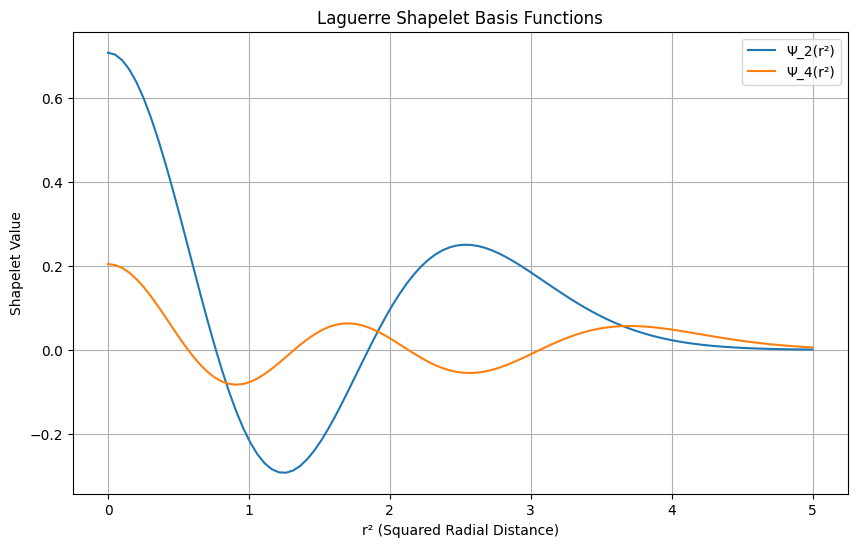

In [4]:
# Create a sample batch of images (B=2, C=1, H=64, W=64)
batch_size = 2
sample_images = torch.zeros((batch_size, 1, 64, 64))

# Create a simple disc in the first image
center1_x, center1_y = 32, 32
radius1 = 16
for y in range(64):
    for x in range(64):
        if ((x - center1_x)**2 + (y - center1_y)**2) < radius1**2:
            sample_images[0, 0, y, x] = 1.0

# Create an ellipse in the second image
center2_x, center2_y = 32, 32
a, b = 20, 10  # Semi-major and semi-minor axes
for y in range(64):
    for x in range(64):
        if ((x - center2_x)**2 / a**2 + (y - center2_y)**2 / b**2) < 1:
            sample_images[1, 0, y, x] = 1.0

# Compute shapelet moments
shapelet_moments = compute_shapelet_moments(sample_images)

# Display results
for i, moments in enumerate(shapelet_moments):
    print(f"Image {i+1} shapelet moments:")
    for key, value in moments.items():
        print(f"  {key}: {value:.6f}")
        
# Visualize shapelet basis functions
visualize_shapelet_basis()